<a href="https://colab.research.google.com/github/Sebacaraballo/ME239---Data-Science-for-ME/blob/main/lecture06/homework_06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

(lecture06:homework)=
# Homework 6

+ Type your name and email in the "Student details" section below.
+ Develop the code and generate the figures you need to solve the problems using this notebook.
+ For the answers that require a mathematical proof or derivation you can either:
    
    - Type the answer using the built-in latex capabilities. In this case, simply export the notebook as a pdf and upload it on gradescope; or
    - You can print the notebook (after you are done with all the code), write your answers by hand, scan, turn your response to a single pdf, and upload on gradescope.

+ The total homework points are 100. Please note that the problems are not weighed equally.

```{note}
+ Please match all the pages corresponding to each of the questions when you submit on gradescope.
```

## Student details

+ **First Name:** Sebastian
+ **Last Name:** Caraballo
+ **Email:** scarabal@purdue.edu

In [1]:
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set(rc={"figure.dpi":100, 'savefig.dpi':300})
sns.set_context('notebook')
sns.set_style("ticks")
from IPython.display import set_matplotlib_formats
set_matplotlib_formats('retina', 'svg')
import requests
import os
def download(url, local_filename=None):
    """
    Downloads the file in the ``url`` and saves it in the current working directory.
    """
    data = requests.get(url)
    if local_filename is None:
        local_filename = os.path.basename(url)
    with open(local_filename, 'wb') as fd:
        fd.write(data.content)

/tmp/ipykernel_10589/1846507495.py:8: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  set_matplotlib_formats('retina', 'svg')


## Problem 1 - Loops and conditionals

Consider the following list:

In [2]:
data = [1, 4, 3, 10, 4, 3, 4, 4]

+ Write a loop that computes the average of the elements in the list and ``print`` the result using two significant digits.

In [3]:
data = [1, 4, 3, 10, 4, 3, 4, 4]

total = 0
for x in data:
    total += x
average = total / len(data)
print(f'{average:.2g}')

4.1


+ Write code that finds the number of times the element 4 occurs in the list. Hint: Use a loop and an if-statement.

In [4]:
count = 0
for x in data:
    if x == 4:
        count += 1
print(count)

4


+ Write a Python function that takes a list as an argument and returns the number of times a given element (also passed as an argument to the function) appears in the list. Call that function ``find_number_of_occurences(a, elm)``. Make sure you follow best practices when writing the docstring of your function.

In [6]:
def find_number_of_occurences(a, elm):
    """
    Count the number of times an element appears in a list.

    Parameters
    ----------
    a : list
        The list to search through.
    elm : any
        The element to search for.

    Returns
    -------
    int
        The number of times elm appears in a.
    """
    count = 0
    for x in a:
        if x == elm:
            count += 1
    return count

In [7]:
# Try it:
help(find_number_of_occurences)

Help on function find_number_of_occurences in module __main__:

find_number_of_occurences(a, elm)
    Count the number of times an element appears in a list.

    Parameters
    ----------
    a : list
        The list to search through.
    elm : any
        The element to search for.

    Returns
    -------
    int
        The number of times elm appears in a.



In [8]:
find_number_of_occurences(data, 4)

4

+ Write a Python function that takes a list as an argument and returns the number of elements that are greater than a given element (also passed as an argument to the function). Call that function ``find_number_of_elms_greater_than(a, elm)``. Make sure you follow best practices when writing the docstring of your function.

In [9]:
def find_number_of_elms_greater_than(a, elm):
    """
    Count the number of elements in a list that are greater than a given value.

    Parameters
    ----------
    a : list
        The list to search through.
    elm : int or float
        The threshold value to compare against.

    Returns
    -------
    int
        The number of elements in a that are strictly greater than elm.
    """
    count = 0
    for x in a:
        if x > elm:
            count += 1
    return count

In [10]:
# Try it:
help(find_number_of_elms_greater_than)

Help on function find_number_of_elms_greater_than in module __main__:

find_number_of_elms_greater_than(a, elm)
    Count the number of elements in a list that are greater than a given value.

    Parameters
    ----------
    a : list
        The list to search through.
    elm : int or float
        The threshold value to compare against.

    Returns
    -------
    int
        The number of elements in a that are strictly greater than elm.



In [11]:
find_number_of_elms_greater_than(data, 3)

5

## Problem 2 - High-performance buildings revisited

In this problem we will continue analyzing the high-performance buildings dataset we introduced in {ref}`lecture03:homework:problem1` and with which we played in {ref}`lecture06:selecting-rows`.
Let me set you up by downloading and cleaning the data file:

In [13]:
import pandas as pd
!curl -O 'https://raw.githubusercontent.com/PurdueMechanicalEngineering/me-239-intro-to-data-science/master/data/temperature_raw.xlsx'

df = pd.read_excel('temperature_raw.xlsx')
df = df.dropna(axis=0)
df.date = pd.to_datetime(df['date'], format='%Y-%m-%d')
df.head()

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  277k  100  277k    0     0   569k      0 --:--:-- --:--:-- --:--:--  570k


,household,date,score,t_out,t_unit,hvac
0,a1,2018-01-07,100.0,4.283373,66.693229,246.473231
1,a10,2018-01-07,100.0,4.283373,66.356134,5.492116
2,a11,2018-01-07,58.0,4.283373,71.549132,402.094327
3,a12,2018-01-07,64.0,4.283373,73.429514,211.692244
4,a13,2018-01-07,100.0,4.283373,63.923937,0.850536


+ Plot the external temperature `t_out`

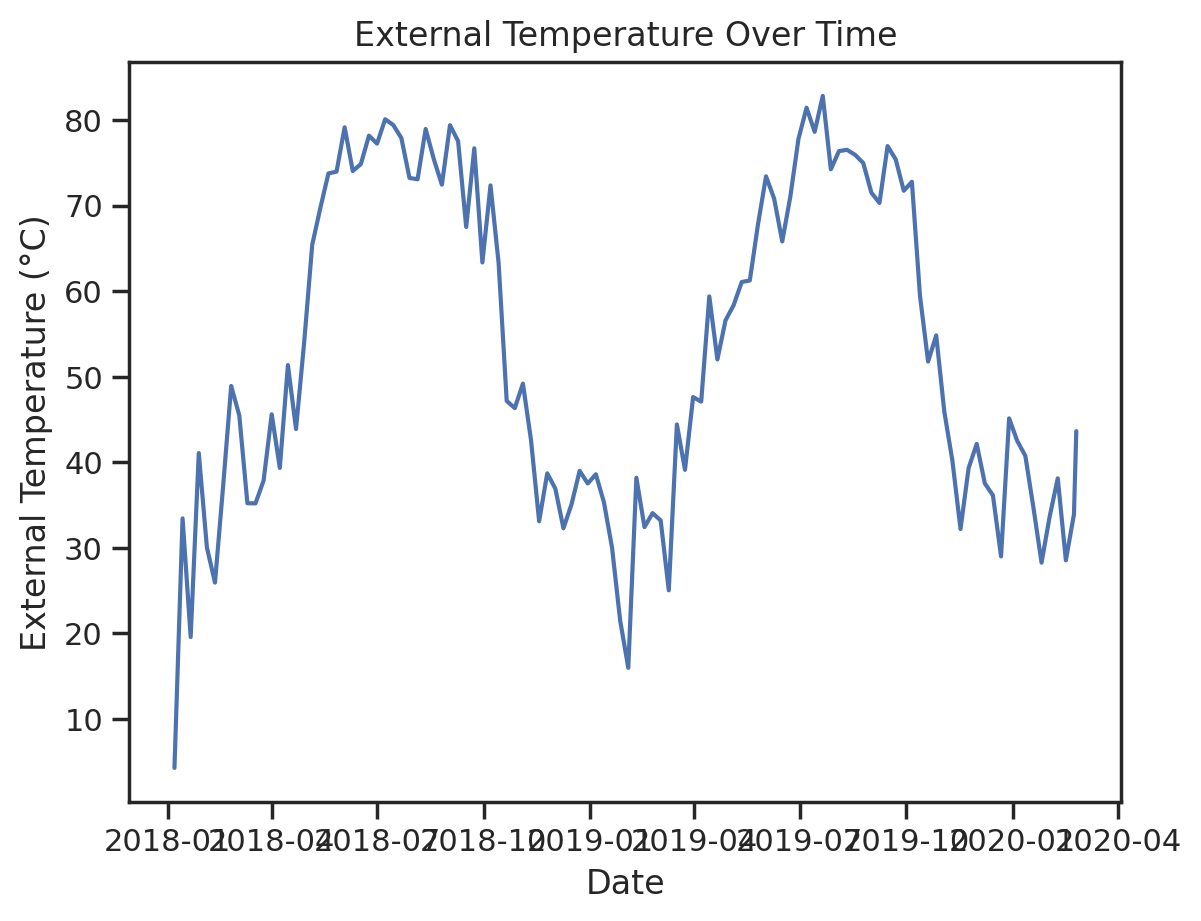

In [14]:
fig, ax = plt.subplots()
ax.plot(df['date'], df['t_out'])
ax.set_xlabel('Date')
ax.set_ylabel('External Temperature (°C)')
ax.set_title('External Temperature Over Time');

+ Extract the data pertaining to household `a5`.
Put the result in a new dataframe called `df_a5`.

In [15]:
df_a5 = df[df['household'] == 'a5']
df_a5.head()

,household,date,score,t_out,t_unit,hvac
11,a5,2018-01-07,64.0,4.283373,74.854456,286.011150
61,a5,2018-01-14,78.0,33.444172,74.786855,137.786711
111,a5,2018-01-21,67.0,19.584102,75.463740,229.760337
161,a5,2018-01-28,74.0,41.076513,75.382341,79.433718
211,a5,2018-02-04,64.0,30.065774,75.676811,118.032515


+ For household `a5`, plot `t_unit` as a function of date.

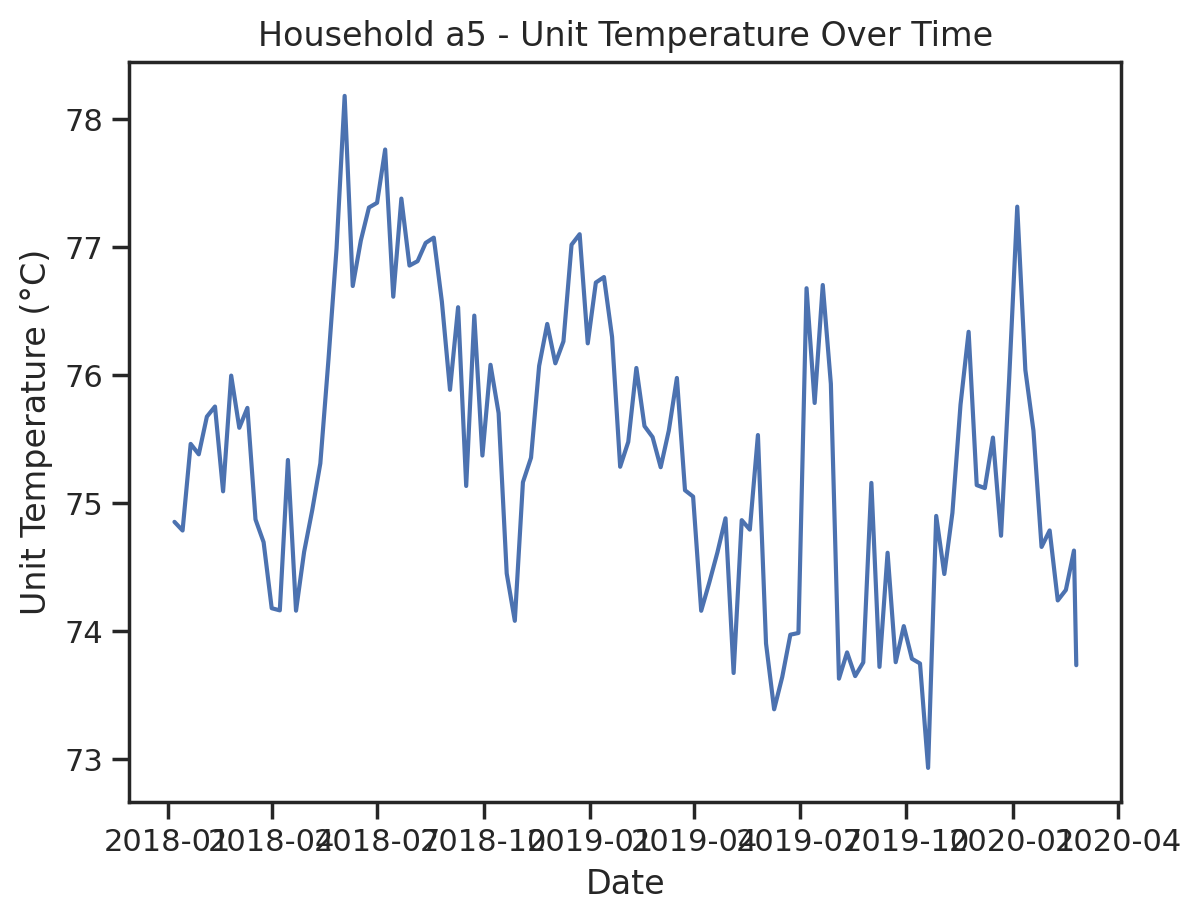

In [16]:
fig, ax = plt.subplots()
ax.plot(df_a5['date'], df_a5['t_unit'])
ax.set_xlabel('Date')
ax.set_ylabel('Unit Temperature (°C)')
ax.set_title('Household a5 - Unit Temperature Over Time');

+ In a single figure, plot `date` vs `t_unit` for households `a5` and `a11`.

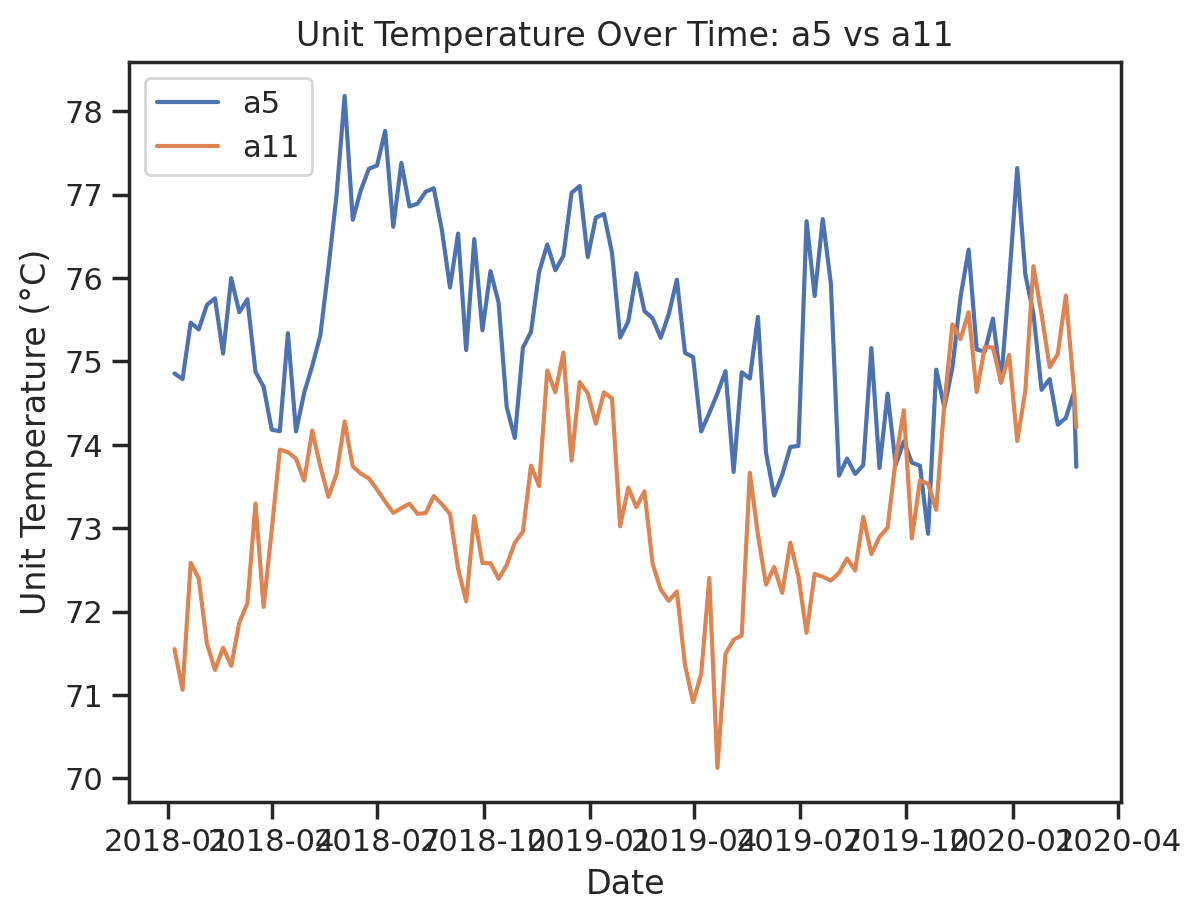

In [17]:
df_a11 = df[df['household'] == 'a11']

fig, ax = plt.subplots()
ax.plot(df_a5['date'], df_a5['t_unit'], label='a5')
ax.plot(df_a11['date'], df_a11['t_unit'], label='a11')
ax.set_xlabel('Date')
ax.set_ylabel('Unit Temperature (°C)')
ax.set_title('Unit Temperature Over Time: a5 vs a11')
ax.legend();

+ In the same figure, plot the `t_out` and `t_unit` scatter plots for both households `a5` and `a11`.

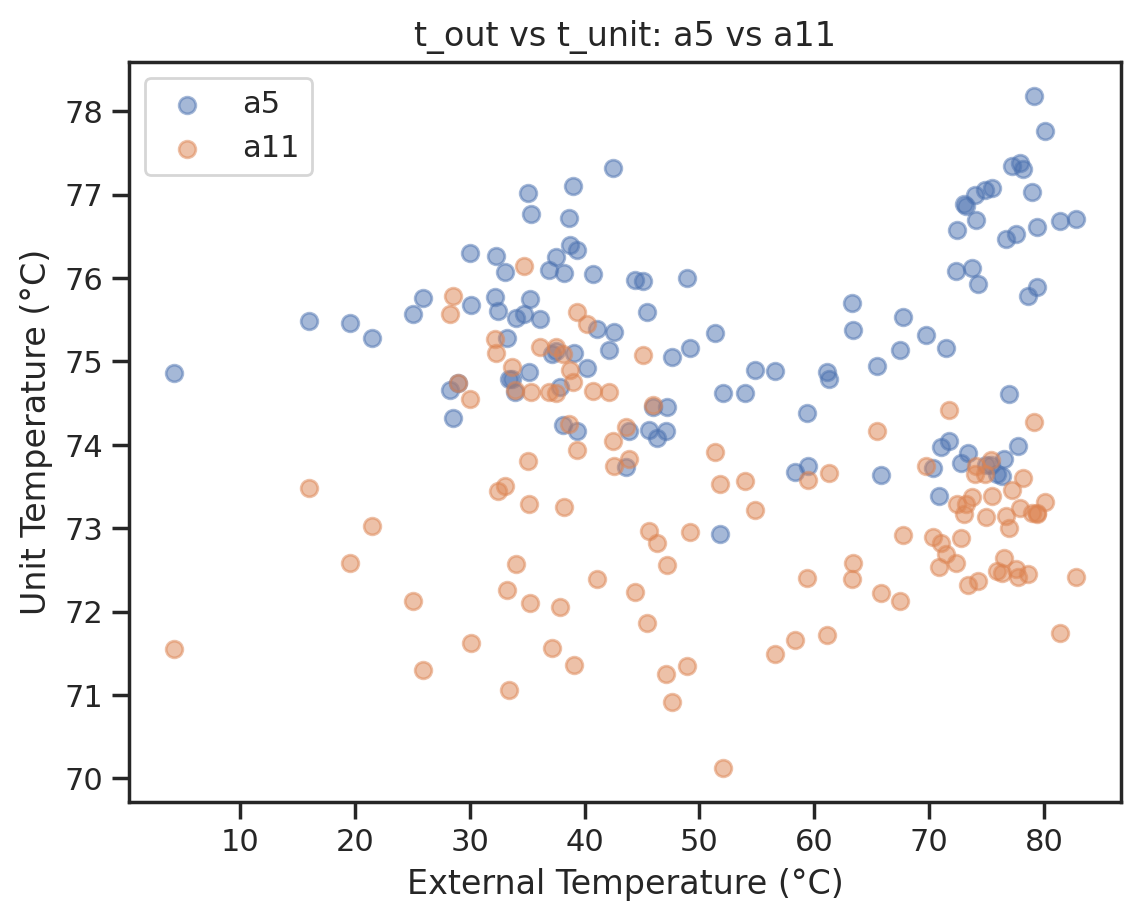

In [18]:
fig, ax = plt.subplots()
ax.scatter(df_a5['t_out'], df_a5['t_unit'], alpha=0.5, label='a5')
ax.scatter(df_a11['t_out'], df_a11['t_unit'], alpha=0.5, label='a11')
ax.set_xlabel('External Temperature (°C)')
ax.set_ylabel('Unit Temperature (°C)')
ax.set_title('t_out vs t_unit: a5 vs a11')
ax.legend();

+ In the same figure, plot the `t_out` and `hvac` scatter plots for both households `a5` and `a11`.

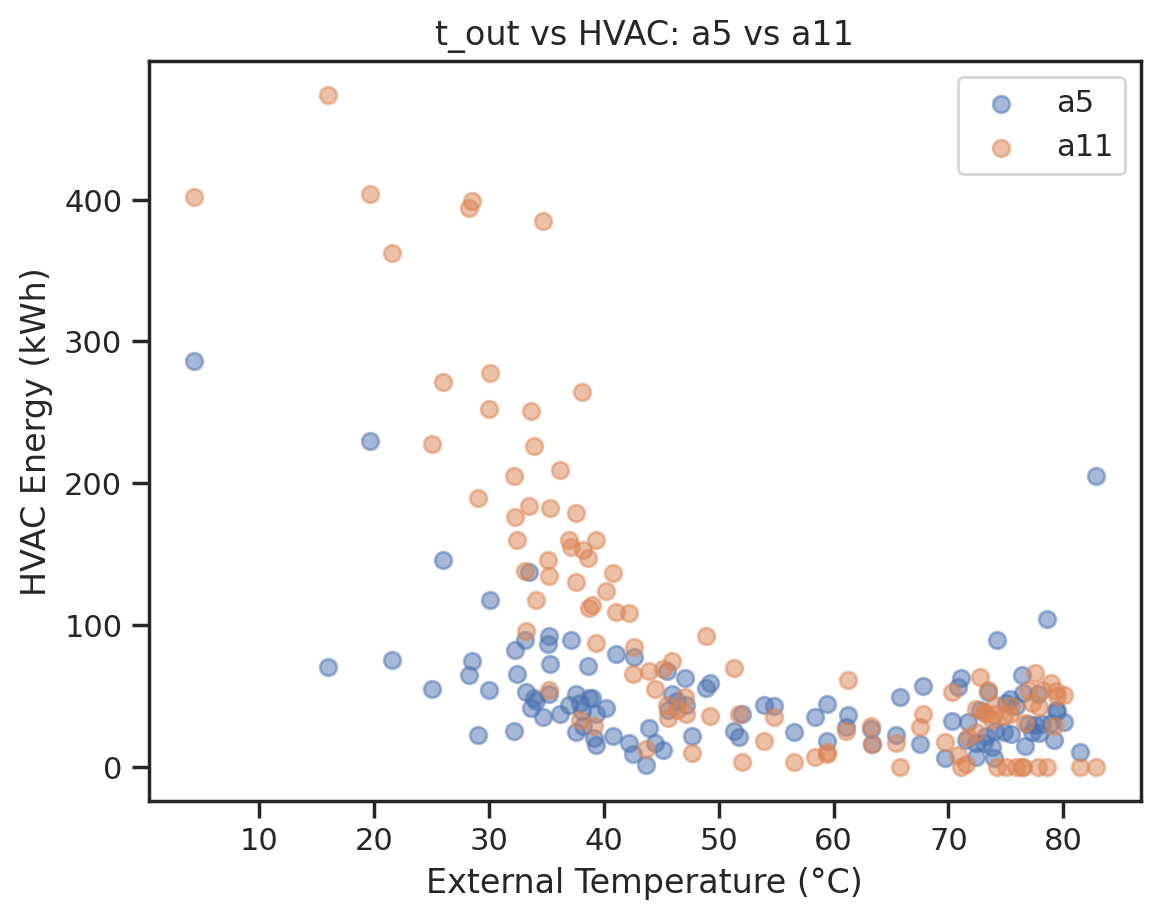

In [19]:
fig, ax = plt.subplots()
ax.scatter(df_a5['t_out'], df_a5['hvac'], alpha=0.5, label='a5')
ax.scatter(df_a11['t_out'], df_a11['hvac'], alpha=0.5, label='a11')
ax.set_xlabel('External Temperature (°C)')
ax.set_ylabel('HVAC Energy (kWh)')
ax.set_title('t_out vs HVAC: a5 vs a11')
ax.legend();

+ In the same figure, plot the histogram of `t_unit` for households `a5` and `a11`.
Which household prefers cooler temperatures?
Hint: To make the histogram more appealing use the keywords ``density=True, alpha=0.25``.

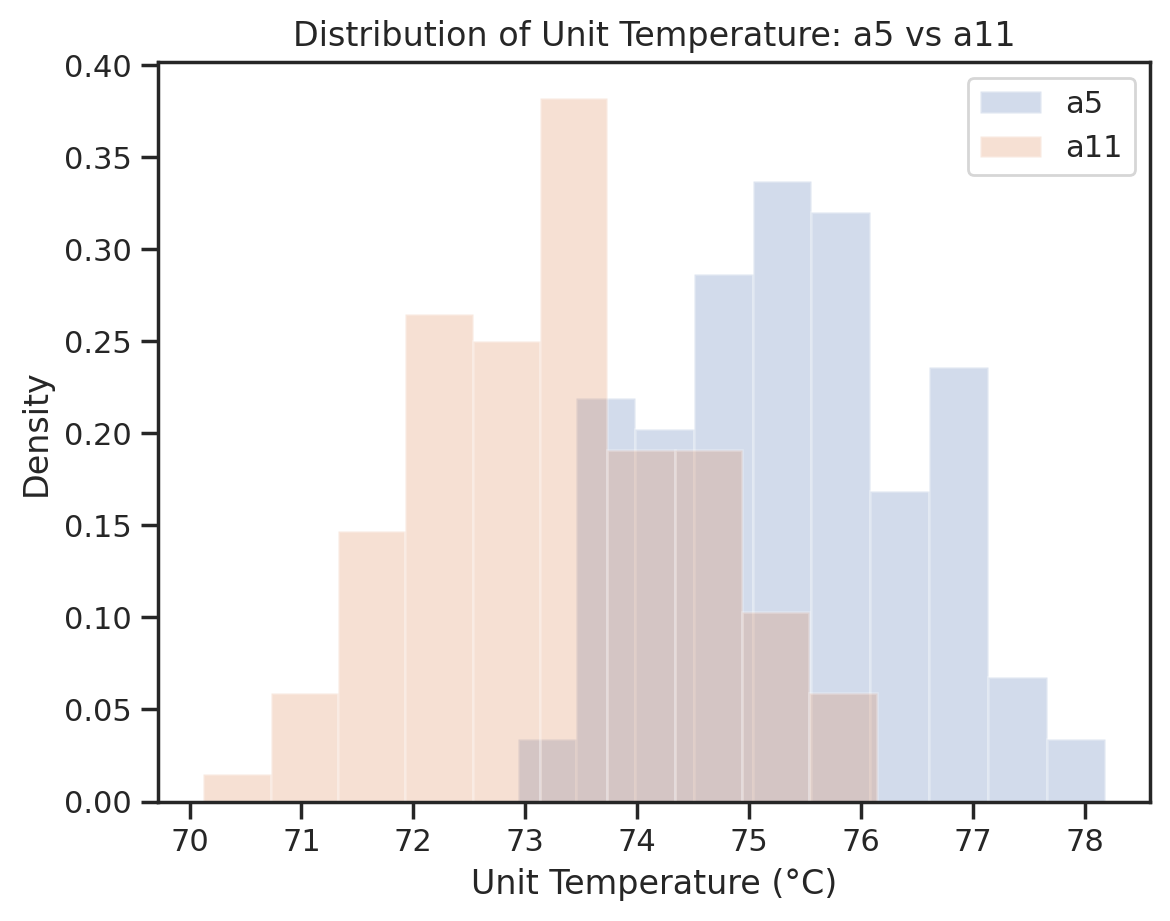

In [20]:
fig, ax = plt.subplots()
ax.hist(df_a5['t_unit'], density=True, alpha=0.25, label='a5')
ax.hist(df_a11['t_unit'], density=True, alpha=0.25, label='a11')
ax.set_xlabel('Unit Temperature (°C)')
ax.set_ylabel('Density')
ax.set_title('Distribution of Unit Temperature: a5 vs a11')
ax.legend();

The household whose histogram is shifted toward lower temperatures prefers cooler indoor conditions. Compare the peaks of the two distributions to determine which one that is.

+ In the same figure, plot the histogram of `hvac` for households `a5` and `a11`.
Which household is more energy efficient (if any) and why?

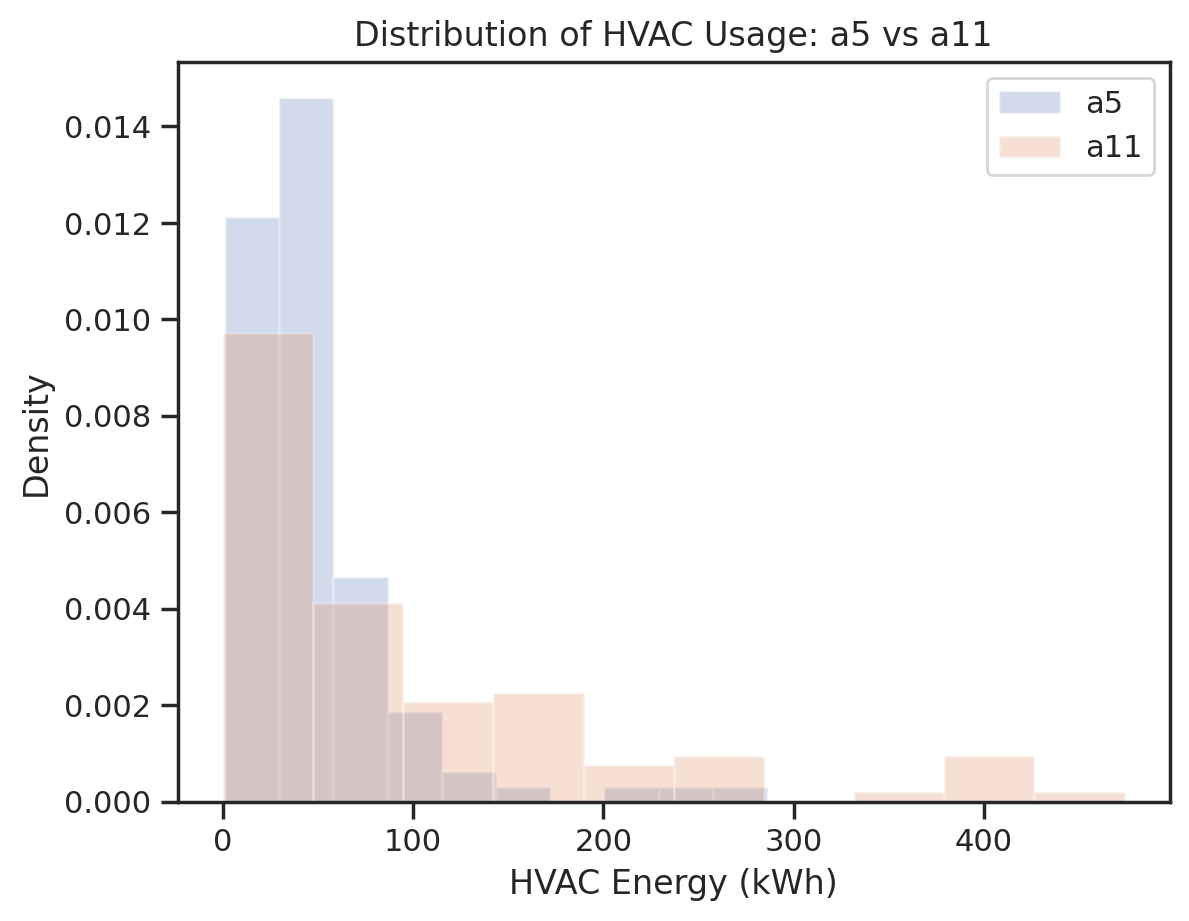

In [21]:
fig, ax = plt.subplots()
ax.hist(df_a5['hvac'], density=True, alpha=0.25, label='a5')
ax.hist(df_a11['hvac'], density=True, alpha=0.25, label='a11')
ax.set_xlabel('HVAC Energy (kWh)')
ax.set_ylabel('Density')
ax.set_title('Distribution of HVAC Usage: a5 vs a11')
ax.legend();

The household whose distribution is shifted toward lower HVAC values is more energy efficient. This could be because they keep their thermostat at a temperature closer to the outdoor temperature, requiring less heating/cooling.

+ Repeat the analysis above for households `b17` and `c40`. Which household prefers cooler temperatures and which one is more energy efficient?

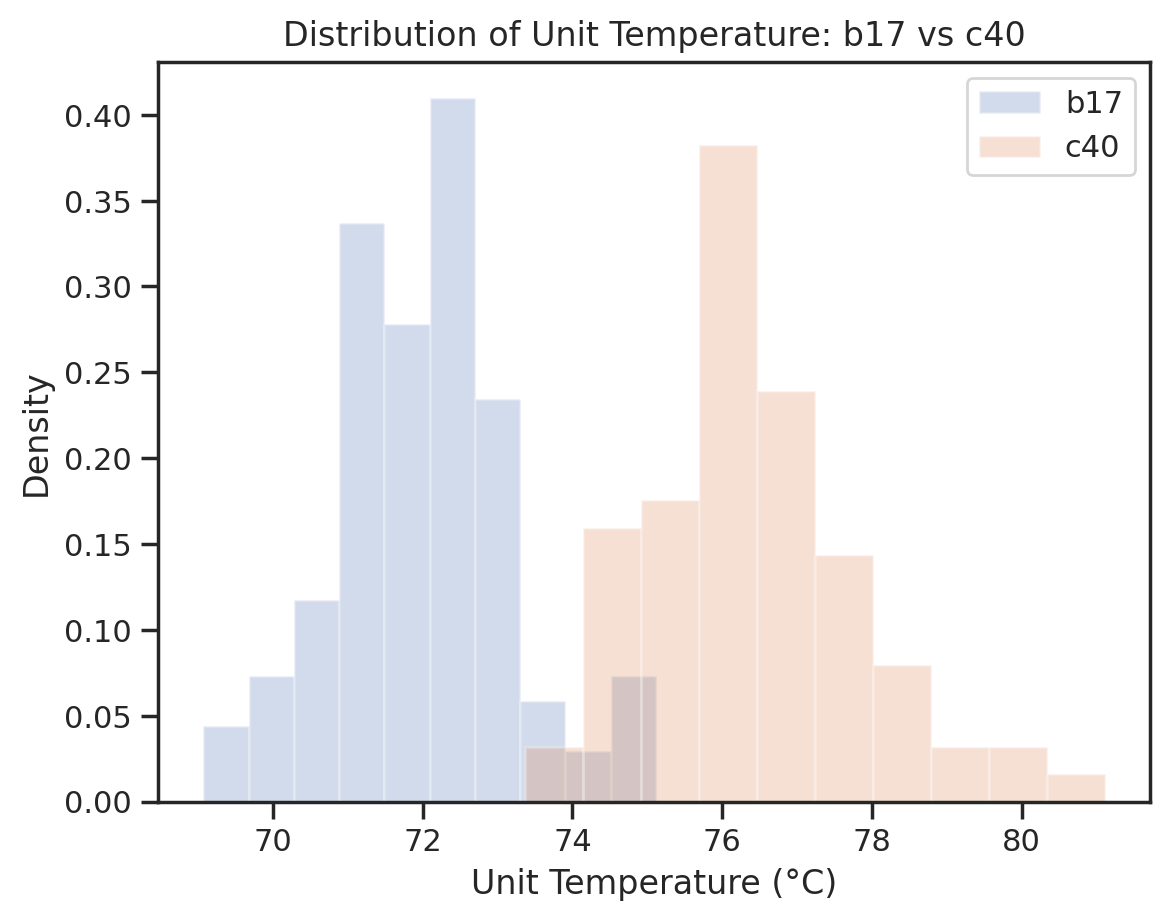

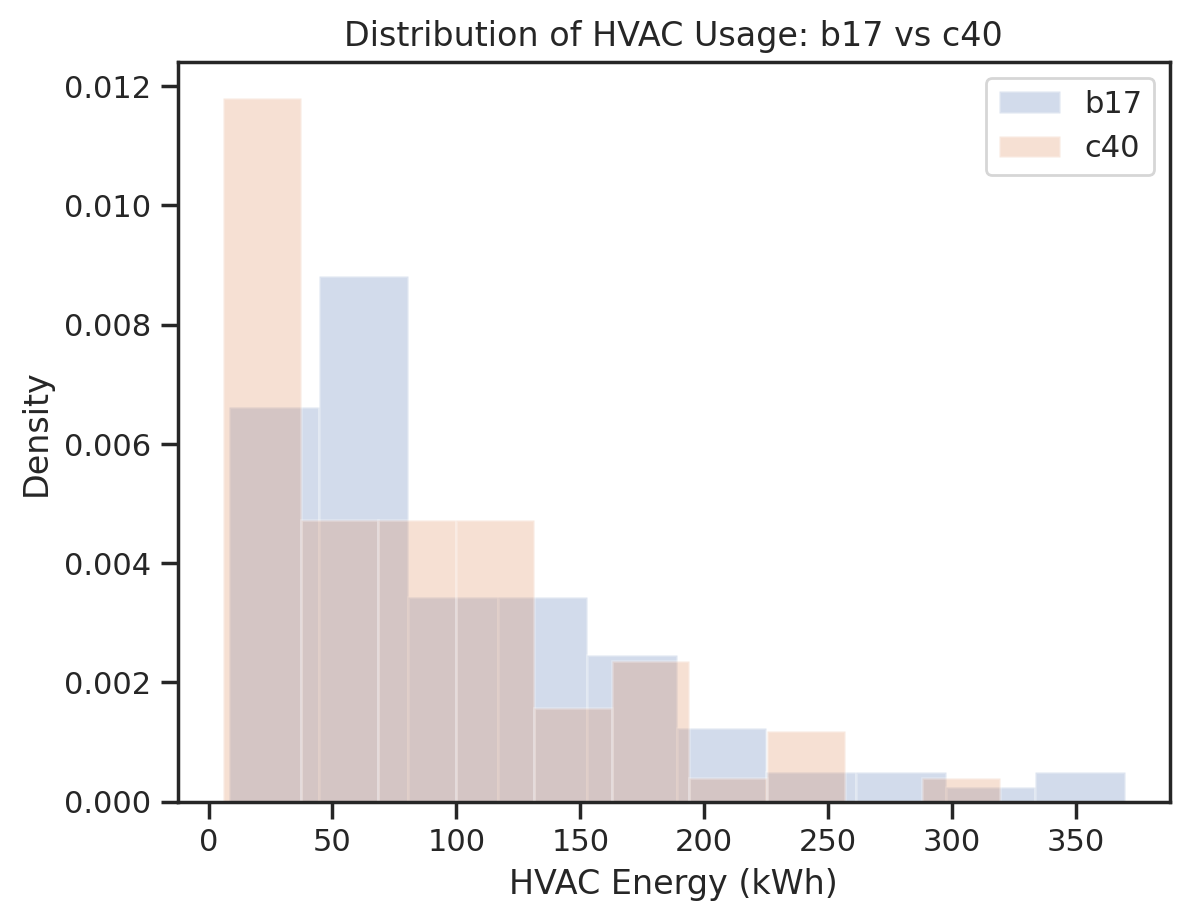

In [22]:
df_b17 = df[df['household'] == 'b17']
df_c40 = df[df['household'] == 'c40']

# t_unit histogram
fig, ax = plt.subplots()
ax.hist(df_b17['t_unit'], density=True, alpha=0.25, label='b17')
ax.hist(df_c40['t_unit'], density=True, alpha=0.25, label='c40')
ax.set_xlabel('Unit Temperature (°C)')
ax.set_ylabel('Density')
ax.set_title('Distribution of Unit Temperature: b17 vs c40')
ax.legend();

# hvac histogram
fig, ax = plt.subplots()
ax.hist(df_b17['hvac'], density=True, alpha=0.25, label='b17')
ax.hist(df_c40['hvac'], density=True, alpha=0.25, label='c40')
ax.set_xlabel('HVAC Energy (kWh)')
ax.set_ylabel('Density')
ax.set_title('Distribution of HVAC Usage: b17 vs c40')
ax.legend();

Compare the two histograms: the household with the lower t_unit peak prefers cooler temperatures, and the one with the lower HVAC peak is more energy efficient. Run the code and observe which distribution sits further left in each plot to give your final answer.

Run the following code to convert the notebook to a pdf. Verify that the file path to the notebook is correct.

In [23]:
from google.colab import drive
drive.mount('/content/drive')
!apt-get install inkscape texlive texlive-xetex texlive-latex-extra pandoc --quiet
!pip install pypandoc --quiet
!jupyter nbconvert --to PDF '/content/drive/MyDrive/Colab Notebooks/Copy of homework_06.ipynb'

Mounted at /content/drive
Reading package lists...
Building dependency tree...
Reading state information...
pandoc is already the newest version (2.9.2.1-3ubuntu2).
pandoc set to manually installed.
The following additional packages will be installed:
  aspell aspell-en at-spi2-core dictionaries-common dvisvgm enchant-2 fig2dev
  fonts-droid-fallback fonts-lato fonts-lmodern fonts-noto-mono fonts-texgyre
  fonts-urw-base35 gawk ghostscript glib-networking glib-networking-common
  glib-networking-services gsettings-desktop-schemas gsfonts hunspell-en-us
  imagemagick imagemagick-6-common imagemagick-6.q16 lib2geom1.1.0
  libapache-pom-java libaspell15 libatk-bridge2.0-0 libatk1.0-0 libatk1.0-data
  libatkmm-1.6-1v5 libatspi2.0-0 libboost-filesystem1.74.0 libcairomm-1.0-1v5
  libcdr-0.1-1 libcommons-logging-java libcommons-parent-java libdbus-glib-1-2
  libdjvulibre-text libdjvulibre21 libdouble-conversion3 libenchant-2-2
  libfftw3-double3 libfontbox-java libgc1 libglibmm-2.4-1v5 libgs9